# 02 — Gap Filling: Source Validation & Merging

**Goal:** Determine whether `SE_PM25.csv` and `pm25_3050456.csv` are good substitutes
for `DK_PM25.csv` during overlap periods, then fill the two known gaps:

| Gap | Source |
|-----|--------|
| December 2023 | SE_PM25.csv |
| November 2025 | pm25_3050456.csv (OpenAQ) |
| Any other missing days | OpenAQ first, SE as fallback |

**Decision criteria:**
- Pearson r ≥ 0.80 during overlap → acceptable substitute
- Mean bias < 5 µg/m³ → no systematic offset correction needed (or apply one if larger)
- If bias is substantial but correlation is high → apply a linear bias correction before filling

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from scipy import stats

plt.rcParams.update({"figure.dpi": 130, "axes.spines.top": False, "axes.spines.right": False})

## 1. Load & Align All Sources

In [3]:
def load_eea(path: str) -> pd.Series:
    """Load EEA CSV → daily mean, timezone-naive, named by path stem."""
    df = pd.read_csv(path, parse_dates=["start"])
    df["start"] = pd.to_datetime(df["start"], utc=True).dt.tz_localize(None)
    df = df.set_index("start").sort_index()
    # Remove sensor errors before daily mean
    df.loc[df["value"] < 0,   "value"] = np.nan
    df.loc[df["value"] >= 300, "value"] = np.nan
    return df["value"].resample("D").mean()


def load_openaq(path: str) -> pd.Series:
    """Load OpenAQ CSV → daily mean, timezone-naive."""
    df = pd.read_csv(path, parse_dates=["date"])
    df["date"] = pd.to_datetime(df["date"], utc=True).dt.tz_localize(None)
    df = df.set_index("date").sort_index()
    df.loc[df["value"] < 0,   "value"] = np.nan
    df.loc[df["value"] >= 300, "value"] = np.nan
    return df["value"].resample("D").mean()


dk = load_eea("../data/raw/eea/DK_PM25.csv")
se = load_eea("../data/raw/eea/SE_PM25.csv")
openaq = load_openaq("../data/raw/openaq/pm25_3050456.csv")

print(f"DK     : {dk.index.min().date()} → {dk.index.max().date()}  ({dk.notna().sum()} days with data)")
print(f"SE     : {se.index.min().date()} → {se.index.max().date()}  ({se.notna().sum()} days with data)")
print(f"OpenAQ : {openaq.index.min().date()} → {openaq.index.max().date()}  ({openaq.notna().sum()} days with data)")

DK     : 2013-01-02 → 2026-05-18  (4619 days with data)
SE     : 2013-01-01 → 2026-05-19  (4674 days with data)
OpenAQ : 2025-10-31 → 2026-05-18  (200 days with data)


## 2. Visual Overview — All Three Sources

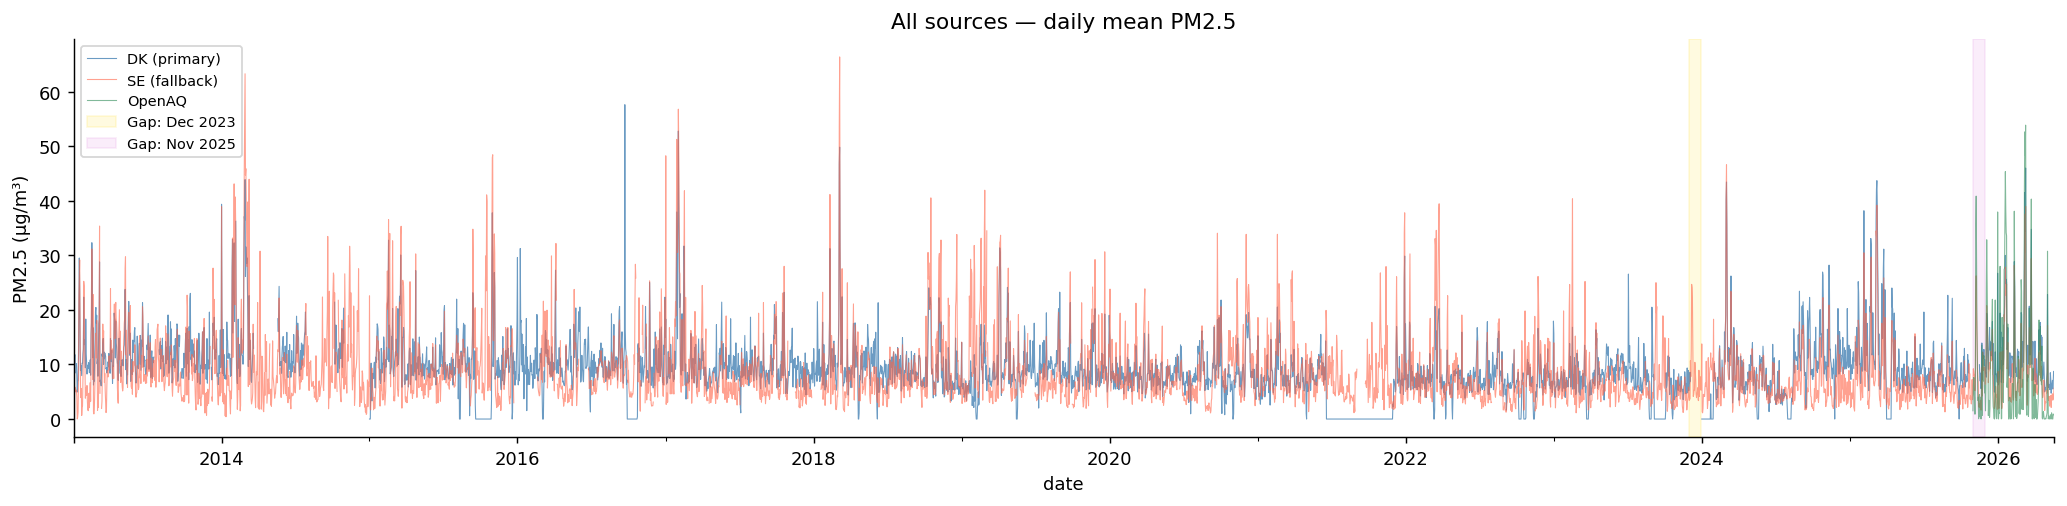

In [4]:
fig, ax = plt.subplots(figsize=(16, 4))

dk.plot(ax=ax,     alpha=0.8, linewidth=0.6, color="steelblue",  label="DK (primary)")
se.plot(ax=ax,     alpha=0.6, linewidth=0.6, color="tomato",     label="SE (fallback)")
openaq.plot(ax=ax, alpha=0.6, linewidth=0.6, color="seagreen",   label="OpenAQ")

# Highlight known gap windows
ax.axvspan(pd.Timestamp("2023-12-01"), pd.Timestamp("2023-12-31"), alpha=0.12, color="gold",   label="Gap: Dec 2023")
ax.axvspan(pd.Timestamp("2025-11-01"), pd.Timestamp("2025-11-30"), alpha=0.12, color="orchid", label="Gap: Nov 2025")

ax.set_title("All sources — daily mean PM2.5")
ax.set_ylabel("PM2.5 (µg/m³)")
ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

## 3. Correlation & Bias During Overlap Periods

Compare each substitute against DK where both have data.
A **good substitute** has r ≥ 0.80 and bias < 5 µg/m³.

In [5]:
def compare_sources(primary: pd.Series, substitute: pd.Series, label: str) -> dict:
    """Compute correlation, bias and RMSE on overlapping non-NaN days."""
    combined = pd.DataFrame({"primary": primary, "substitute": substitute}).dropna()
    if len(combined) < 10:
        print(f"{label}: insufficient overlap ({len(combined)} days)")
        return {}

    r, p        = stats.pearsonr(combined["primary"], combined["substitute"])
    bias        = (combined["substitute"] - combined["primary"]).mean()
    rmse        = np.sqrt(((combined["substitute"] - combined["primary"]) ** 2).mean())
    n           = len(combined)

    print(f"\n{'─'*45}")
    print(f"  {label}  (n={n} overlapping days)")
    print(f"{'─'*45}")
    print(f"  Pearson r  : {r:.3f}  (p={p:.2e})")
    print(f"  Mean bias  : {bias:+.2f} µg/m³  (substitute − primary)")
    print(f"  RMSE       : {rmse:.2f} µg/m³")
    verdict = "✅ Good substitute" if r >= 0.80 and abs(bias) < 5 else \
              "⚠️  Usable with bias correction" if r >= 0.80 else \
              "❌ Poor substitute"
    print(f"  Verdict    : {verdict}")

    return {"label": label, "r": r, "bias": bias, "rmse": rmse, "n": n, "data": combined}


res_se     = compare_sources(dk, se,     "DK vs SE")
res_openaq = compare_sources(dk, openaq, "DK vs OpenAQ")


─────────────────────────────────────────────
  DK vs SE  (n=4411 overlapping days)
─────────────────────────────────────────────
  Pearson r  : 0.649  (p=0.00e+00)
  Mean bias  : -0.55 µg/m³  (substitute − primary)
  RMSE       : 5.22 µg/m³
  Verdict    : ❌ Poor substitute

─────────────────────────────────────────────
  DK vs OpenAQ  (n=184 overlapping days)
─────────────────────────────────────────────
  Pearson r  : 0.925  (p=1.18e-78)
  Mean bias  : -3.35 µg/m³  (substitute − primary)
  RMSE       : 6.95 µg/m³
  Verdict    : ✅ Good substitute


In [14]:
# Might be affected too much by periods we arent interested in anyway so I will compare the period just before the period we are missing 
res_se = compare_sources(
    dk.loc["2023-11-01":"2023-11-30"],
    se.loc["2023-11-01":"2023-11-30"],
    "DK vs SE (Octoeber+November 2023 only)"
)


─────────────────────────────────────────────
  DK vs SE (Octoeber+November 2023 only)  (n=30 overlapping days)
─────────────────────────────────────────────
  Pearson r  : 0.391  (p=3.29e-02)
  Mean bias  : -1.84 µg/m³  (substitute − primary)
  RMSE       : 2.56 µg/m³
  Verdict    : ❌ Poor substitute


## 4. Decision

Decisions based on findings.

Since SE $PM_{2.5}$ is such a bad approximation of DK $PM_{2.5}$, I will not use SE data. Instead I will have the following prioritization of fillings:

> 1. **OpenAQ** (where available): Pearson r = 0.925 against DK on 184 overlapping days — actual measurements from the same location after bias correction. Real observations always preferred over statistical fills.
> 2. **Linear interpolation** (gaps ≤ 7 days): For short gaps, the values immediately before and after are highly informative given lag-1 autocorrelation of r = 0.66. A straight line between two real observations is a better local estimate than any historical average.
> 3. **Conditional mean imputation** (gaps > 7 days with no substitute source): Each missing day is filled with the mean of that calendar day (e.g. December 1st) across all observed years, excluding the gap year. This conditions on seasonal patterns specific to the same station, which Quinteros et al. (2019) found to be the best performing approach for month-long gaps in fixed ambient monitoring stations with extended historical records.